In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

import joblib

#CARGAR DATASET

archivo = "dataset_examenes.csv"

df = pd.read_csv(archivo)

print("Dataset cargado")
print(df.head())

# ---------- SEPARAR VARIABLES ----------

X = df.drop("nivel_asignado", axis=1)

y = df["nivel_asignado"]

# ---------- CONVERTIR TEXTO A NUMEROS ----------

encoder = LabelEncoder()

y = encoder.fit_transform(y)

# ---------- DIVIDIR DATASET ----------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------- CREAR MODELO ----------

modelo = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42
)

# ---------- ENTRENAR ----------

modelo.fit(X_train, y_train)

print("Modelo entrenado")

# ---------- EVALUAR ----------

y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", accuracy)

# ---------- GUARDAR MODELO ----------

joblib.dump(modelo, "modelo_random_forest.pkl")

# Guardar encoder también
joblib.dump(encoder, "encoder.pkl")

print("Modelo guardado como modelo_random_forest.pkl")

Dataset cargado
   aciertos_totales  vidas_perdidas  pistas_usadas  tiempo_total_segundos  \
0                 8               7              3                     91   
1                 7               4              3                    135   
2                 6               5              3                    126   
3                 5               6              6                    135   
4                 6               2              1                    191   

   max_racha_correctas  errores_traducir  errores_completar  errores_imagenes  \
0                    3                 4                  1                 2   
1                    2                 1                  1                 2   
2                    5                 2                  2                 1   
3                    3                 1                  3                 2   
4                    3                 1                  0                 1   

  nivel_asignado  
0        Basico

In [17]:
import pandas as pd

df = pd.read_csv("dataset_examenes.csv")

print(df.columns)

Index(['aciertos_totales', 'vidas_perdidas', 'pistas_usadas',
       'tiempo_total_segundos', 'max_racha_correctas', 'errores_traducir',
       'errores_completar', 'errores_imagenes', 'nivel_asignado'],
      dtype='str')


In [15]:
duplicados = df.duplicated().sum()

print("Duplicados:", duplicados)

Duplicados: 0


In [18]:
print(df["nivel_asignado"].value_counts())

nivel_asignado
Basico        35759
Basico+       10630
Intermedio     3611
Name: count, dtype: int64


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93      7179
           1       0.77      0.78      0.77      2112
           2       0.93      0.21      0.34       709

    accuracy                           0.87     10000
   macro avg       0.87      0.65      0.68     10000
weighted avg       0.88      0.87      0.86     10000



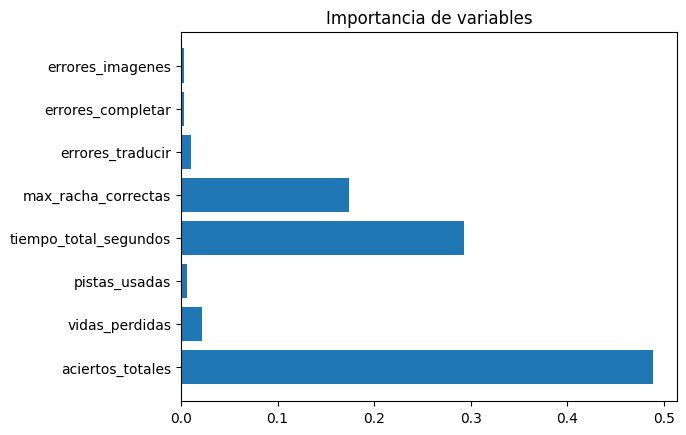

In [20]:
import matplotlib.pyplot as plt

importancias = modelo.feature_importances_

nombres = X.columns

plt.barh(nombres, importancias)
plt.title("Importancia de variables")
plt.show()

In [21]:
print(df.describe())

       aciertos_totales  vidas_perdidas  pistas_usadas  tiempo_total_segundos  \
count      50000.000000    50000.000000    50000.00000           50000.000000   
mean           4.731600        4.798080        3.87854             241.431560   
std            2.674544        2.930665        2.40023             108.511027   
min            0.000000        0.000000        0.00000              20.000000   
25%            3.000000        2.000000        2.00000             162.000000   
50%            5.000000        5.000000        4.00000             236.000000   
75%            7.000000        7.000000        5.00000             315.000000   
max           10.000000       10.000000       10.00000             623.000000   

       max_racha_correctas  errores_traducir  errores_completar  \
count         50000.000000      50000.000000        50000.00000   
mean              2.520460          2.164880            1.67412   
std               2.079622          1.716867            1.45660   
mi